In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sns
import networkx as nx

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [2]:
fc_kp = pd.read_csv("../../data/filtered_clusters_for_RSchage_kp.tsv", sep="\t")
fc_ec = pd.read_csv("../../data/filtered_clusters_for_RSchage_ec.tsv", sep="\t")

kp = pd.read_csv("../../data/kpneumo/kpneumoniae_data_2023.tsv", sep="\t")
ec = pd.read_csv("../../data/ecoli/ecoli_data_2023.tsv", sep="\t")

coi_kp = pd.read_csv("../../data/cluster_resistance_change_kp.tsv", sep="\t")
coi_ec = pd.read_csv("../../data/cluster_resistance_change_ec.tsv", sep="\t")

ec_vir = pd.read_csv("../../data/ecoli_virulence_score.tsv", sep="\t")
ec_amr = pd.read_csv("../../data/ecoli_resistance_score.tsv", sep="\t")

ec_vir = pd.read_csv("../../data/ecoli_virulence_score.tsv", sep="\t")
ec_amr = pd.read_csv("../../data/ecoli_resistance_score.tsv", sep="\t")

<ipython-input-2-4d05545fd188>:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  fc_ec = pd.read_csv("../../data/filtered_clusters_for_RSchage_ec.tsv", sep="\t")


In [3]:
fc_kp = fc_kp[["sample1", "sample2", "snps", "expected_snps", "CI", "date_diff", "transmission_20SNP", "transmission_180d"]]
fc_ec = fc_ec[["sample1", "sample2", "snps", "expected_snps", "CI", "date_diff", "transmission_20SNP", "transmission_180d"]]

In [4]:
kp_sc3 = kp[kp.SC == "3"]

In [5]:
kp_sc3["Consent"].unique()

array(['public', 'hospital', nan], dtype=object)

In [6]:
kp_sc3.loc[kp_sc3["collection"] == "MHH", "hospital_loc"] = kp_sc3.loc[kp_sc3["collection"] == "MHH", "hospital_loc"].fillna("Germany")
kp_sc3.loc[kp_sc3["collection"] == "CPH", "hospital_loc"] = kp_sc3.loc[kp_sc3["collection"] == "CPH", "hospital_loc"].fillna("Denmark")
kp_sc3.loc[kp_sc3["collection"] == "MHH", "isolation_source_categ"] = kp_sc3.loc[kp_sc3["collection"] == "MHH", "isolation_source_categ"].fillna("human")
kp_sc3.loc[kp_sc3["collection"] == "CPH", "isolation_source_categ"] = kp_sc3.loc[kp_sc3["collection"] == "CPH", "isolation_source_categ"].fillna("human")
kp_sc3.loc[kp_sc3["collection"] == "MHH", "Consent"] = kp_sc3.loc[kp_sc3["collection"] == "MHH", "Consent"].fillna("hospital")
kp_sc3.loc[kp_sc3["collection"] == "CPH", "Consent"] = kp_sc3.loc[kp_sc3["collection"] == "CPH", "Consent"].fillna("hospital")

In [7]:
# match coi with full SC3 df
kp_sc3["coi"] = kp_sc3["sampleid"].isin(coi_kp["sample"]).astype(int)

<ipython-input-7-66178dab6bd7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kp_sc3["coi"] = kp_sc3["sampleid"].isin(coi_kp["sample"]).astype(int)


In [8]:
kp_sc3[["coi", "resistance_score"]].value_counts()

coi  resistance_score
0    0.0                 176
     1.0                  78
     2.0                  43
1    0.0                   4
0    3.0                   3
1    1.0                   1
dtype: int64

In [9]:
kp_sc3.to_csv("../../out/RS_changes/kp_sc3/kp_sc3.tsv", sep="\t", index=None)

In [10]:
ec_sc4 = ec[ec.SC == "4"]

In [11]:
ec_sc4.loc[ec_sc4["collection"] == "MHH", "hospital_loc"] = ec_sc4.loc[ec_sc4["collection"] == "MHH", "hospital_loc"].fillna("Germany")
ec_sc4.loc[ec_sc4["collection"] == "CPH", "hospital_loc"] = ec_sc4.loc[ec_sc4["collection"] == "CPH", "hospital_loc"].fillna("Denmark")
ec_sc4.loc[ec_sc4["collection"] == "MHH", "isolation_source_categ"] = ec_sc4.loc[ec_sc4["collection"] == "MHH", "isolation_source_categ"].fillna("human")
ec_sc4.loc[ec_sc4["collection"] == "CPH", "isolation_source_categ"] = ec_sc4.loc[ec_sc4["collection"] == "CPH", "isolation_source_categ"].fillna("human")
ec_sc4.loc[ec_sc4["collection"] == "MHH", "Consent"] = ec_sc4.loc[ec_sc4["collection"] == "MHH", "Consent"].fillna("hospital")
ec_sc4.loc[ec_sc4["collection"] == "CPH", "Consent"] = ec_sc4.loc[ec_sc4["collection"] == "CPH", "Consent"].fillna("hospital")

In [12]:
ec_sc4 = ec_sc4.merge(ec_vir[["Isolate", "score"]], left_on="sampleid", right_on="Isolate", how="left")
ec_sc4 = ec_sc4.drop(columns="Isolate").rename(columns={"score": "virulence_score"})

ec_sc4 = ec_sc4.merge(ec_amr[["Isolate", "resistance_score"]], left_on="sampleid", right_on="Isolate", how="left")

In [13]:
# match coi with full SC3 df
ec_sc4["coi"] = ec_sc4["sampleid"].isin(coi_ec["sample"]).astype(int)

In [14]:
ec_sc4[["coi", "resistance_score"]].value_counts()

coi  resistance_score
0    0.0                 791
     3.0                 773
1    3.0                 222
     0.0                  43
0    1.0                  11
1    1.0                   2
dtype: int64

In [15]:
ec_sc4_mhh = ec_sc4[(ec_sc4["coi"] == 1) & (ec_sc4["collection"] == "MHH")]

In [16]:
ec_sc4_mhh = ec_sc4[ec_sc4["collection"] == "MHH"]

In [17]:
ec_sc4_mhh["coi"].value_counts()

0    504
1    170
Name: coi, dtype: int64

In [18]:
ec_sc4_mhh.to_csv("../../out/RS_changes/ec_sc4/ec_sc4_mhh.tsv", sep="\t", index=None)
ec_sc4.to_csv("../../out/RS_changes/ec_sc4/ec_sc4.tsv", sep="\t", index=None)

In [19]:
kp_sc3_mhh = kp_sc3[kp_sc3["collection"] == "MHH"]

### ABX treatment

In [27]:
abx = pd.read_excel("../../data/2025-07-23_AntibioticTherapies_samplePats.xlsx")

In [28]:
abx

,pat_id,corresponding_stay,received_antibiotic_treatment,substance,begin,end
0,2a646c7238bb0784af93e67f56b7ad47,inpatient,yes,piperacillin-tazobactam,2022-01-12,2022-01-25
1,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,linezolid,2022-02-16,2022-02-23
2,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,ciprofloxacin,2022-02-15,2022-02-23
3,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,fosfomycin,2022-01-18,2022-01-18
4,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,piperacillin-tazobactam,2022-01-28,2022-02-06
5,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,ceftriaxon,2022-01-31,2022-02-06
6,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,vancomycin,2022-02-06,2022-02-16
7,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,moxifloxacin,2022-02-07,2022-02-15
8,cbaa51b517eefdca2ab2a1cebbf06aab,inpatient,yes,erythromycin,2022-02-10,2022-02-15
9,1b7ccf1caca28a0f64dfd941fffa1ccc,inpatient,yes,ampicillin-sulbactam,2021-12-09,2021-12-09


In [44]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

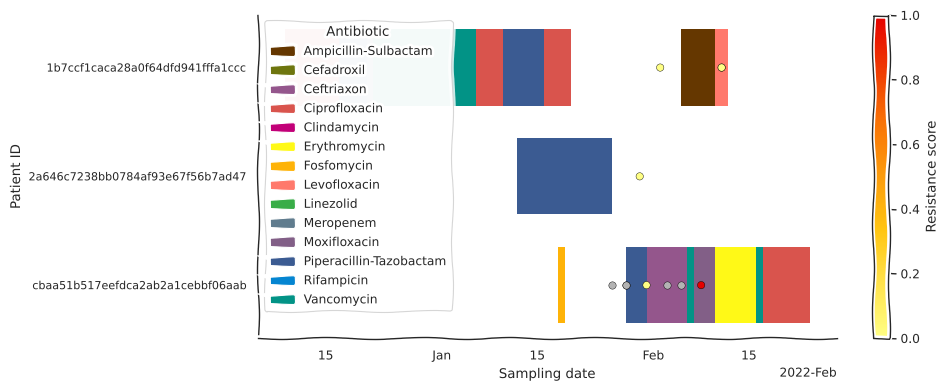

In [48]:
# --- filter & prep ---
pts = set(abx['pat_id'])
df = kp_sc3_mhh.loc[kp_sc3_mhh['pat_id'].isin(pts)].copy()
abx_df = abx.loc[abx['pat_id'].isin(pts)].copy()

df['samplingdate'] = pd.to_datetime(df['samplingdate'])
df['resistance_score'] = pd.to_numeric(df['resistance_score'], errors='coerce')

abx_df['begin'] = pd.to_datetime(abx_df['begin'], errors='coerce')
abx_df['end']   = pd.to_datetime(abx_df['end'], errors='coerce')
abx_df = abx_df[
    (abx_df['received_antibiotic_treatment'].str.lower() == 'yes') &
    abx_df['begin'].notna() & abx_df['end'].notna() &
    (abx_df['end'] >= abx_df['begin'])
].copy()

# normalize substance labels to avoid KeyError
abx_df['substance_norm'] = (
    abx_df['substance'].astype(str).str.strip().str.lower()
)
# display labels (title-case)
abx_df['substance_label'] = abx_df['substance_norm'].str.replace('_',' ').str.title()

# y positions (ordered by first sample date)
order = df.groupby('pat_id')['samplingdate'].min().sort_values().index
ypos  = {pid:i for i,pid in enumerate(order, 1)}
df['y'] = df['pat_id'].map(ypos)
abx_df['y'] = abx_df['pat_id'].map(ypos)

# palettes
xkcd_cont = LinearSegmentedColormap.from_list(
    "rscore_xkcd", sns.xkcd_palette(['pale yellow','sunflower','orange','red'])
)
drug_levels = abx_df['substance_norm'].dropna().unique().tolist()
# cycle colors if many drugs
xkcd_names = ['denim blue','medium green','pale red','amber','purplish','teal',
              'dusty purple','sunny yellow','brown','blue grey','salmon','olive',
              'cerulean','magenta','dark mint','peach','slate']
drug_colors = sns.xkcd_palette(xkcd_names[:max(1, len(drug_levels))])
drug2color  = {d:c for d,c in zip(drug_levels, drug_colors)}

# --- plot (clean: no grid, no extra lines) ---
sns.set_theme(style="white", context="paper")
fig_h = max(4, min(0.45*len(order), 14))
fig, ax = plt.subplots(figsize=(10, fig_h))
sns.despine(ax=ax, top=True, right=True)
ax.grid(False)

# antibiotic bars — one per row (patient-specific)
for _, r in abx_df.iterrows():
    start = mdates.date2num(r['begin'])
    width = (r['end'] - r['begin']).days + 1
    ax.broken_barh(
        [(start, width)],
        (r['y'] - 0.35, 0.7),
        facecolors=drug2color.get(r['substance_norm'], '#666'),
        edgecolors='none',
        zorder=1
    )

# samples (all points; continuous resistance color)
vals = df['resistance_score'].to_numpy()
vmin = np.nanmin(vals) if np.isfinite(vals).any() else 0.0
vmax = np.nanmax(vals) if np.isfinite(vals).any() else 1.0
norm = Normalize(vmin=vmin, vmax=vmax)

has_score = df['resistance_score'].notna()
ax.scatter(
    df.loc[has_score,'samplingdate'], df.loc[has_score,'y'],
    c=xkcd_cont(norm(df.loc[has_score,'resistance_score'])),
    s=28, edgecolors='black', linewidths=0.3, zorder=2
)
if (~has_score).any():
    ax.scatter(
        df.loc[~has_score,'samplingdate'], df.loc[~has_score,'y'],
        color='0.7', s=28, edgecolors='black', linewidths=0.3, zorder=2,
        label='No resistance score'
    )

# axes
ax.set_yticks(range(1, len(order)+1))
ax.set_yticklabels(order, fontsize=8)
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.set_xlabel("Sampling date")
ax.set_ylabel("Patient ID")

# colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap=xkcd_cont); mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax); cbar.set_label("Resistance score")

# antibiotic legend (by substance)
legend_labels = (abx_df[['substance_norm','substance_label']]
                 .drop_duplicates().sort_values('substance_label'))
handles = [Patch(facecolor=drug2color[s], label=lab)
           for s, lab in legend_labels.itertuples(index=False, name=None)]
leg = ax.legend(handles=handles, title="Antibiotic", frameon=True,
                facecolor="white", loc='best')

plt.tight_layout()
plt.show()

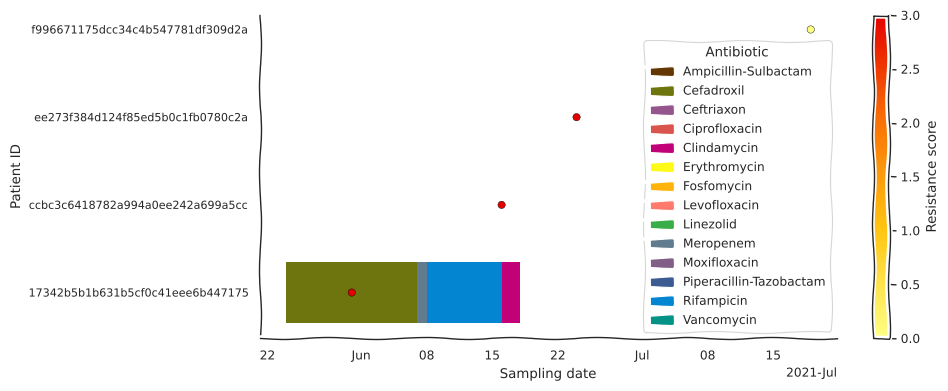

In [51]:
# --- filter & prep ---
pts = set(abx['pat_id'])
df = ec_sc4_mhh.loc[ec_sc4_mhh['pat_id'].isin(pts)].copy()
abx_df = abx.loc[abx['pat_id'].isin(pts)].copy()

df['samplingdate'] = pd.to_datetime(df['samplingdate'])
df['resistance_score'] = pd.to_numeric(df['resistance_score'], errors='coerce')

abx_df['begin'] = pd.to_datetime(abx_df['begin'], errors='coerce')
abx_df['end']   = pd.to_datetime(abx_df['end'], errors='coerce')
abx_df = abx_df[
    (abx_df['received_antibiotic_treatment'].str.lower() == 'yes') &
    abx_df['begin'].notna() & abx_df['end'].notna() &
    (abx_df['end'] >= abx_df['begin'])
].copy()

# normalize substance labels to avoid KeyError
abx_df['substance_norm'] = (
    abx_df['substance'].astype(str).str.strip().str.lower()
)
# display labels (title-case)
abx_df['substance_label'] = abx_df['substance_norm'].str.replace('_',' ').str.title()

# y positions (ordered by first sample date)
order = df.groupby('pat_id')['samplingdate'].min().sort_values().index
ypos  = {pid:i for i,pid in enumerate(order, 1)}
df['y'] = df['pat_id'].map(ypos)
abx_df['y'] = abx_df['pat_id'].map(ypos)

# palettes
xkcd_cont = LinearSegmentedColormap.from_list(
    "rscore_xkcd", sns.xkcd_palette(['pale yellow','sunflower','orange','red'])
)
drug_levels = abx_df['substance_norm'].dropna().unique().tolist()
# cycle colors if many drugs
xkcd_names = ['denim blue','medium green','pale red','amber','purplish','teal',
              'dusty purple','sunny yellow','brown','blue grey','salmon','olive',
              'cerulean','magenta','dark mint','peach','slate']
drug_colors = sns.xkcd_palette(xkcd_names[:max(1, len(drug_levels))])
drug2color  = {d:c for d,c in zip(drug_levels, drug_colors)}

# --- plot (clean: no grid, no extra lines) ---
sns.set_theme(style="white", context="paper")
fig_h = max(4, min(0.45*len(order), 14))
fig, ax = plt.subplots(figsize=(10, fig_h))
sns.despine(ax=ax, top=True, right=True)
ax.grid(False)

# antibiotic bars — one per row (patient-specific)
for _, r in abx_df.iterrows():
    start = mdates.date2num(r['begin'])
    width = (r['end'] - r['begin']).days + 1
    ax.broken_barh(
        [(start, width)],
        (r['y'] - 0.35, 0.7),
        facecolors=drug2color.get(r['substance_norm'], '#666'),
        edgecolors='none',
        zorder=1
    )

# samples (all points; continuous resistance color)
vals = df['resistance_score'].to_numpy()
vmin = np.nanmin(vals) if np.isfinite(vals).any() else 0.0
vmax = np.nanmax(vals) if np.isfinite(vals).any() else 1.0
norm = Normalize(vmin=vmin, vmax=vmax)

has_score = df['resistance_score'].notna()
ax.scatter(
    df.loc[has_score,'samplingdate'], df.loc[has_score,'y'],
    c=xkcd_cont(norm(df.loc[has_score,'resistance_score'])),
    s=28, edgecolors='black', linewidths=0.3, zorder=2
)
if (~has_score).any():
    ax.scatter(
        df.loc[~has_score,'samplingdate'], df.loc[~has_score,'y'],
        color='0.7', s=28, edgecolors='black', linewidths=0.3, zorder=2,
        label='No resistance score'
    )

# axes
ax.set_yticks(range(1, len(order)+1))
ax.set_yticklabels(order, fontsize=8)
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.set_xlabel("Sampling date")
ax.set_ylabel("Patient ID")

# colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap=xkcd_cont); mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax); cbar.set_label("Resistance score")

# antibiotic legend (by substance)
legend_labels = (abx_df[['substance_norm','substance_label']]
                 .drop_duplicates().sort_values('substance_label'))
handles = [Patch(facecolor=drug2color[s], label=lab)
           for s, lab in legend_labels.itertuples(index=False, name=None)]
leg = ax.legend(handles=handles, title="Antibiotic", frameon=True,
                facecolor="white", loc='best')

plt.tight_layout()
plt.show()